In [4]:
import numpy as np

def fake_cfd_sim(camber, thickness, Re, alpha, model_type, rng):
    # 1) base physics-like relation
    base = (
        0.8
        + 2.0 * (camber - 0.3)**2
        + 1.5 * (thickness - 0.15)**2
        + 0.000001 * (1e6 / Re)  # Re สูง drag ลด
        + 0.05 * np.abs(alpha)   # AoA สูง drag สูง
    )

    # 2) stall-like regime (discontinuity)
    if np.abs(alpha) > 12:
        base += 0.5 + 0.05 * (np.abs(alpha) - 12)**2

    # 3) model bias (physics model layer)
    if model_type == 0:
        # โมเดลง่าย: เพี้ยนหนักเวลาใกล้ stall
        bias = 0.1 * np.tanh((np.abs(alpha) - 8)/3)
    else:
        # โมเดลดี: เพี้ยนเบากว่า
        bias = 0.04 * np.tanh((np.abs(alpha) - 8)/3)

    # 4) manufacturing / measurement noise
    noise = rng.normal(scale=0.01)

    return base + bias + noise

In [5]:
from sklearn.model_selection import train_test_split

rng = np.random.default_rng(42)
N = 20000

camber = rng.uniform(0.0, 0.6, size=N)
thickness = rng.uniform(0.08, 0.25, size=N)
Re = rng.uniform(2e5, 2e6, size=N)
alpha = rng.uniform(-15, 15, size=N)
model_type = rng.integers(0, 2, size=N)

y = np.array([
    fake_cfd_sim(c, t, r, a, m, rng)
    for c, t, r, a, m in zip(camber, thickness, Re, alpha, model_type)
])

X = np.column_stack([camber, thickness, Re, alpha, model_type])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [6]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

rf = RandomForestRegressor(
    n_estimators=400,
    max_depth=12,
    random_state=42,
    n_jobs=-1,
)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print("Test MSE:", mse)

Test MSE: 0.0003477284567253551


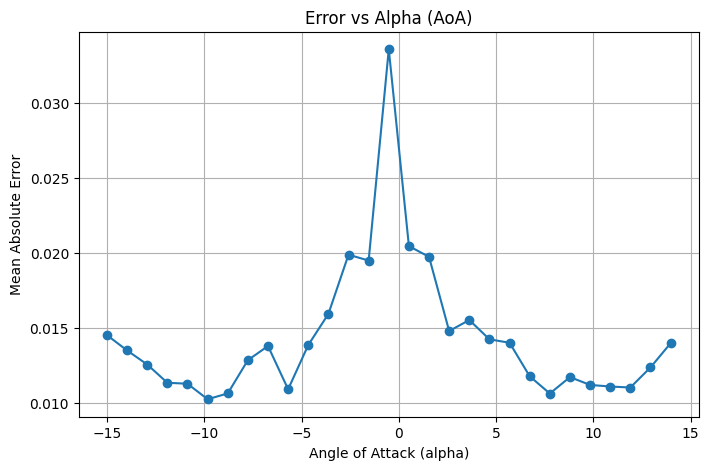

In [7]:
import matplotlib.pyplot as plt
import numpy as np

errors = np.abs(y_test - y_pred)
alpha_test = X_test[:, 3]

bins = np.linspace(-15, 15, 30)
bin_idx = np.digitize(alpha_test, bins)

mean_err = [errors[bin_idx == i].mean() for i in range(1, len(bins))]

plt.figure(figsize=(8,5))
plt.plot(bins[:-1], mean_err, marker='o')
plt.xlabel("Angle of Attack (alpha)")
plt.ylabel("Mean Absolute Error")
plt.title("Error vs Alpha (AoA)")
plt.grid(True)
plt.show()

In [8]:
model_type_test = X_test[:, 4]
err_model0 = errors[model_type_test == 0].mean()
err_model1 = errors[model_type_test == 1].mean()

print("Error for model_type 0:", err_model0)
print("Error for model_type 1:", err_model1)

Error for model_type 0: 0.014613171944503732
Error for model_type 1: 0.014255869272219933


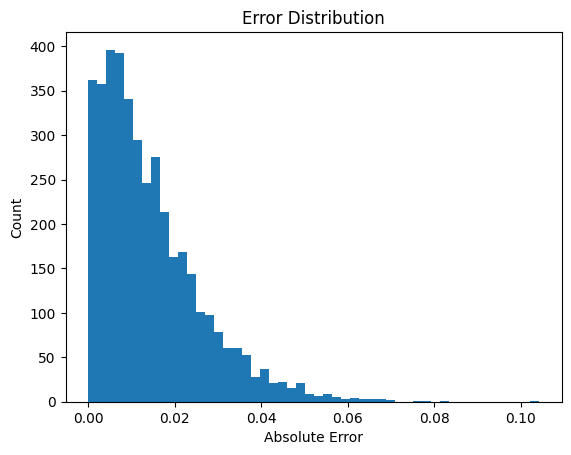

In [9]:
plt.hist(errors, bins=50)
plt.xlabel("Absolute Error")
plt.ylabel("Count")
plt.title("Error Distribution")
plt.show()

In [10]:
pip install torch


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip3.12 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [11]:
# Cell 1: imports & seed
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

In [12]:
# Cell 2: fake CFD simulator

def fake_cfd_multi_regime(camber, thickness, Re, alpha_deg,
                          model_type, mesh_fidelity, rng):
    """
    camber, thickness : 0~1
    Re                : 2e5 ~ 2e6
    alpha_deg         : -15 ~ 15
    model_type        : 0,1 (turbulence model)
    mesh_fidelity     : 0..1 (0 = coarse, 1 = fine)
    Return: "Cd-like" scalar
    """
    alpha = np.deg2rad(alpha_deg)

    # 1) base term shared by all regimes (non-dim)
    Re_ref = 5e5
    base = 0.02 \
        + 0.6 * (camber - 0.3)**2 \
        + 0.4 * (thickness - 0.12)**2 \
        + 0.5 * (Re_ref / Re)**0.3 \
        + 0.04 * alpha**2

    # 2) determine regime
    #   laminar-ish
    if Re < 3e5 and abs(alpha_deg) < 5:
        regime = "A"
    #   attached turbulent
    elif abs(alpha_deg) <= 10:
        regime = "B"
    #   stalled / separated
    else:
        regime = "C"

    # 3) regime-specific contribution (nonlinear)
    if regime == "A":
        reg_term = 0.01 * np.exp(-abs(alpha_deg) / 5.0)
    elif regime == "B":
        reg_term = 0.015 + 0.003 * abs(alpha_deg)
    else:  # C
        reg_term = 0.04 + 0.003 * (abs(alpha_deg) - 10)**2

    # 4) model bias: model_type 0 แย่กว่าใน regime C
    if model_type == 0:
        bias = 0.0
        if regime == "C":
            bias += 0.02 * np.tanh((abs(alpha_deg) - 10) / 3.0)
    else:  # model_type == 1
        bias = 0.0
        if regime == "A":
            bias -= 0.005 * np.tanh((3 - abs(alpha_deg)) / 2.0)

    # 5) mesh fidelity effect (coarse mesh → เพิ่ม drag & noise)
    mesh_bias = (1.0 - mesh_fidelity) * 0.01
    mesh_noise = rng.normal(scale=0.003 + 0.004 * (1.0 - mesh_fidelity))

    # 6) final
    y = base + reg_term + bias + mesh_bias + mesh_noise
    return y

In [13]:
# Cell 3: dataset generation

rng = np.random.default_rng(42)
N = 30000

camber     = rng.uniform(0.05, 0.6, size=N)
thickness  = rng.uniform(0.08, 0.2, size=N)
Re         = rng.uniform(2e5, 2e6, size=N)
alpha_deg  = rng.uniform(-15, 15, size=N)
model_type = rng.integers(0, 2, size=N)      # 0 or 1
mesh_fid   = rng.uniform(0.4, 1.0, size=N)   # 0.4~1.0

y = np.array([
    fake_cfd_multi_regime(c, t, r, a, m, mf, rng)
    for c, t, r, a, m, mf in zip(camber, thickness, Re,
                                 alpha_deg, model_type, mesh_fid)
])

# stack inputs
X = np.column_stack([
    camber, thickness, Re, alpha_deg, model_type, mesh_fid
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train.shape, X_test.shape

((24000, 6), (6000, 6))

In [14]:
# Cell 4: scaling & dataset

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

class CFDDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32).unsqueeze(-1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_ds = CFDDataset(X_train_scaled, y_train)
test_ds  = CFDDataset(X_test_scaled, y_test)

train_loader = DataLoader(train_ds, batch_size=256, shuffle=True)
test_loader  = DataLoader(test_ds, batch_size=512, shuffle=False)

In [15]:
# Cell 5: MoE model

class MLPExpert(nn.Module):
    def __init__(self, input_dim, hidden_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, x):
        return self.net(x)  # (B,1)


class MoECFDSurrogate(nn.Module):
    def __init__(self, input_dim, n_experts=3, hidden_dim=64):
        super().__init__()
        self.n_experts = n_experts

        # gating network
        self.gating = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, n_experts)
        )

        # expert networks
        self.experts = nn.ModuleList([
            MLPExpert(input_dim, hidden_dim)
            for _ in range(n_experts)
        ])

    def forward(self, x):
        # x: (B, D)
        gate_logits = self.gating(x)           # (B, E)
        gate = F.softmax(gate_logits, dim=-1)  # (B, E)

        # expert outputs
        expert_outs = [expert(x) for expert in self.experts]  # list of (B,1)
        expert_outs = torch.stack(expert_outs, dim=-1)        # (B,1,E)
        expert_outs = expert_outs.squeeze(1)                  # (B,E)

        # weighted sum
        y_hat = (gate * expert_outs).sum(dim=-1, keepdim=True)  # (B,1)
        return y_hat, gate, expert_outs

In [16]:
# Cell 6: training

model = MoECFDSurrogate(input_dim=X_train_scaled.shape[1],
                        n_experts=3, hidden_dim=64).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()

def evaluate(loader):
    model.eval()
    total_loss = 0.0
    n = 0
    with torch.no_grad():
        for Xb, yb in loader:
            Xb, yb = Xb.to(device), yb.to(device)
            y_hat, _, _ = model(Xb)
            loss = criterion(y_hat, yb)
            total_loss += loss.item() * len(Xb)
            n += len(Xb)
    return total_loss / n

n_epochs = 40
for epoch in range(1, n_epochs+1):
    model.train()
    running = 0.0
    n_train = 0
    for Xb, yb in train_loader:
        Xb, yb = Xb.to(device), yb.to(device)
        optimizer.zero_grad()
        y_hat, gate, expert_outs = model(Xb)
        loss = criterion(y_hat, yb)
        loss.backward()
        optimizer.step()

        running += loss.item() * len(Xb)
        n_train += len(Xb)

    train_loss = running / n_train
    test_loss = evaluate(test_loader)

    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch:02d} | train MSE={train_loss:.6f} "
              f"| test MSE={test_loss:.6f}")

Epoch 01 | train MSE=0.016137 | test MSE=0.001260
Epoch 05 | train MSE=0.000220 | test MSE=0.000210
Epoch 10 | train MSE=0.000131 | test MSE=0.000135
Epoch 15 | train MSE=0.000102 | test MSE=0.000110
Epoch 20 | train MSE=0.000082 | test MSE=0.000085
Epoch 25 | train MSE=0.000065 | test MSE=0.000070
Epoch 30 | train MSE=0.000054 | test MSE=0.000061
Epoch 35 | train MSE=0.000047 | test MSE=0.000054
Epoch 40 | train MSE=0.000042 | test MSE=0.000046


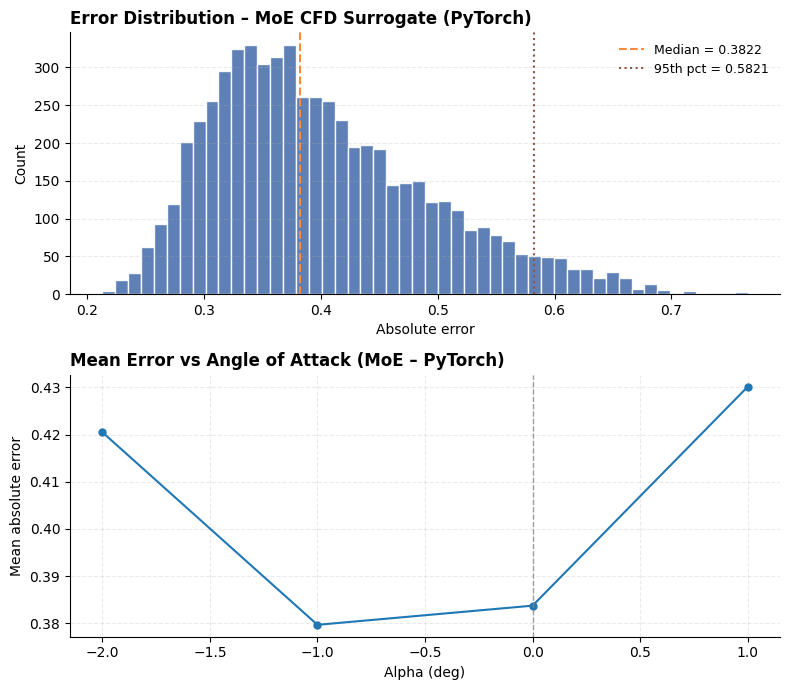

In [41]:
# Cell 7: evaluation & visualization (PyTorch MoE)

model.eval()
all_err = []
all_alpha = []

with torch.no_grad():
    # ดึง Xorig จาก test_ds โดยไม่ shuffle เพื่อให้ลำดับตรงกับ loader
    for (Xb, yb), (Xorig, _) in zip(
        test_loader,
        DataLoader(test_ds, batch_size=test_loader.batch_size, shuffle=False)
    ):
        Xb, yb = Xb.to(device), yb.to(device)
        y_hat, gate, expert_outs = model(Xb)
        err = torch.abs(y_hat - yb).cpu().numpy().ravel()

        all_err.append(err)

        # alpha (deg) อยู่ที่ column 3 ของ feature ก่อน scaling
        alpha_deg_batch = Xorig[:, 3]   # สมมติ Xorig เป็น numpy หรือ tensor shape (B, d)
        alpha_deg_batch = (
            alpha_deg_batch.numpy() if isinstance(alpha_deg_batch, torch.Tensor)
            else alpha_deg_batch
        )
        all_alpha.append(alpha_deg_batch)

# concat ให้เป็น 1D array
all_err = np.concatenate(all_err)
alpha_test = np.concatenate(all_alpha)

# ---------------------------------------------------
# 1) Error distribution (histogram + quantiles)
# ---------------------------------------------------
bins_alpha = np.linspace(-15, 15, 31)
bin_idx = np.digitize(alpha_test, bins_alpha)
mean_err = np.full(len(bins_alpha) - 1, np.nan)

for i in range(1, len(bins_alpha)):
    m = bin_idx == i
    if m.any():
        mean_err[i-1] = all_err[m].mean()

valid = ~np.isnan(mean_err)

median_err = np.median(all_err)
p95_err = np.percentile(all_err, 95)

fig, axes = plt.subplots(2, 1, figsize=(8, 7), sharex=False)

# (a) Error histogram
ax1 = axes[0]
ax1.hist(
    all_err,
    bins=50,
    color="#4c72b0",
    edgecolor="white",
    alpha=0.9,
)
ax1.set_xlabel("Absolute error", fontsize=10)
ax1.set_ylabel("Count", fontsize=10)
ax1.set_title(
    "Error Distribution – MoE CFD Surrogate (PyTorch)",
    fontsize=12,
    fontweight="bold",
    loc="left",
)

ax1.axvline(median_err, color="#ff8a3c", linestyle="--", linewidth=1.5,
            label=f"Median = {median_err:.4f}")
ax1.axvline(p95_err, color="#8c564b", linestyle=":", linewidth=1.5,
            label=f"95th pct = {p95_err:.4f}")

ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.grid(axis="y", linestyle="--", alpha=0.25)
ax1.legend(frameon=False, fontsize=9, loc="upper right")

# ---------------------------------------------------
# 2) Mean |error| vs alpha
# ---------------------------------------------------
ax2 = axes[1]
ax2.plot(
    bins_alpha[:-1][valid],
    mean_err[valid],
    marker="o",
    linestyle="-",
    linewidth=1.5,
    markersize=5,
)

ax2.axvline(0.0, color="#888888", linestyle="--", linewidth=1.0, alpha=0.8)

ax2.set_xlabel("Alpha (deg)", fontsize=10)
ax2.set_ylabel("Mean absolute error", fontsize=10)
ax2.set_title(
    "Mean Error vs Angle of Attack (MoE – PyTorch)",
    fontsize=12,
    fontweight="bold",
    loc="left",
)

ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)
ax2.grid(True, linestyle="--", alpha=0.25)

plt.tight_layout()
plt.show()

In [18]:
# Cell: Gating analysis
model.eval()
with torch.no_grad():
    Xb = torch.tensor(X_test_scaled, dtype=torch.float32).to(device)
    y_hat, gates, expert_outs = model(Xb)   # gates: (N,E), expert_outs: (N,E)

gates_np = gates.cpu().numpy()
experts_np = expert_outs.cpu().numpy()
y_hat_np = y_hat.cpu().numpy().ravel()

alpha_test = X_test[:, 3]   # AoA (deg) จาก data เดิม
Re_test    = X_test[:, 2]   # Reynolds

In [19]:
import numpy as np

winner = gates_np.argmax(axis=1)   # expert index ที่ gate สูงสุด
unique, counts = np.unique(winner, return_counts=True)
for u, c in zip(unique, counts):
    print(f"Expert {u}: {c} samples ({c/len(winner)*100:.1f}%)")

Expert 0: 762 samples (12.7%)
Expert 1: 230 samples (3.8%)
Expert 2: 5008 samples (83.5%)


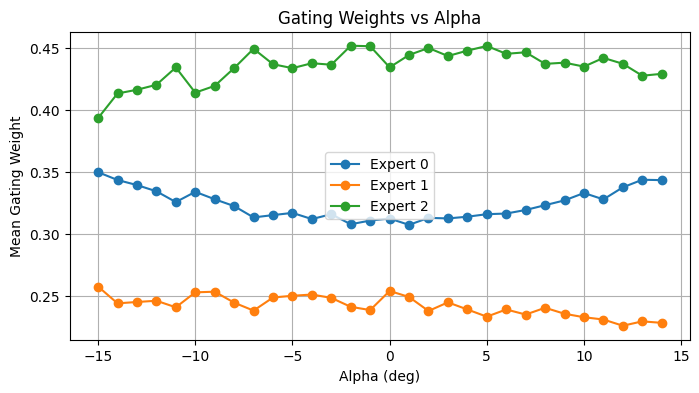

In [20]:
import matplotlib.pyplot as plt

E = gates_np.shape[1]
bins = np.linspace(-15, 15, 31)
bin_idx = np.digitize(alpha_test, bins)

mean_gate = np.zeros((len(bins)-1, E))
for i in range(1, len(bins)):
    m = bin_idx == i
    if m.any():
        mean_gate[i-1, :] = gates_np[m].mean(axis=0)

plt.figure(figsize=(8,4))
for e in range(E):
    plt.plot(bins[:-1], mean_gate[:, e], marker="o", label=f"Expert {e}")
plt.xlabel("Alpha (deg)")
plt.ylabel("Mean Gating Weight")
plt.title("Gating Weights vs Alpha")
plt.legend()
plt.grid(True)
plt.show()

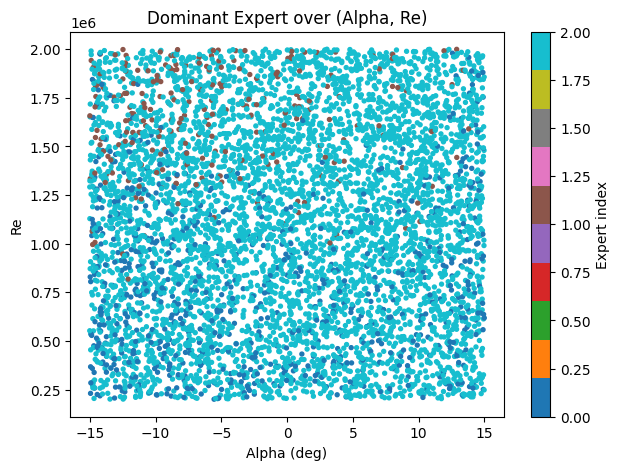

In [21]:
plt.figure(figsize=(7,5))
sc = plt.scatter(alpha_test, Re_test, c=winner, cmap="tab10", s=8)
plt.xlabel("Alpha (deg)")
plt.ylabel("Re")
plt.title("Dominant Expert over (Alpha, Re)")
plt.colorbar(sc, label="Expert index")
plt.show()

In [22]:
def moe_uncertainty(model, X_np, batch_size=512):
    """
    X_np: numpy array (N, D) — scaled แล้ว
    return: predictive variance จากความไม่เห็นพ้องของ experts (N,)
    """
    model.eval()
    ds = CFDDataset(X_np, np.zeros(len(X_np)))
    loader = DataLoader(ds, batch_size=batch_size, shuffle=False)

    all_var = []
    with torch.no_grad():
        for Xb, _ in loader:
            Xb = Xb.to(device)
            y_hat, gates, expert_outs = model(Xb)      # (B,1), (B,E), (B,E)
            mean = y_hat                               # (B,1)
            # predictive variance ~ Σ g_i (f_i - mean)^2
            diff2 = (expert_outs - mean) ** 2          # (B,E)
            var = (gates * diff2).sum(dim=-1)          # (B,)
            all_var.append(var.cpu().numpy())
    return np.concatenate(all_var)

In [23]:
# สร้าง pool (unlabeled) จาก distribution เดิม หรือ distribution ใหม่
N_pool = 20000
camber_p     = rng.uniform(0.05, 0.6, size=N_pool)
thickness_p  = rng.uniform(0.08, 0.2, size=N_pool)
Re_p         = rng.uniform(2e5, 2e6, size=N_pool)
alpha_deg_p  = rng.uniform(-15, 15, size=N_pool)
model_type_p = rng.integers(0, 2, size=N_pool)
mesh_fid_p   = rng.uniform(0.4, 1.0, size=N_pool)

X_pool = np.column_stack([camber_p, thickness_p, Re_p,
                          alpha_deg_p, model_type_p, mesh_fid_p])

X_pool_scaled = scaler.transform(X_pool)

In [24]:
K = 500  # จำนวนเคสที่เราจะส่งไป run CFD จริงในรอบนี้

unc = moe_uncertainty(model, X_pool_scaled)
idx_top = np.argsort(-unc)[:K]  # เรียงจากมากไปน้อย

X_new = X_pool[idx_top]         # ยังไม่ scaled เพื่อส่งเข้า solver จริง
X_new_scaled = X_pool_scaled[idx_top]

In [25]:
y_new = np.array([
    fake_cfd_multi_regime(c, t, r, a, m, mf, rng)
    for c, t, r, a, m, mf in X_new
])

In [26]:
# ต่อข้อมูลเข้า training set
X_train = np.vstack([X_train, X_new])
y_train = np.concatenate([y_train, y_new])

# re-scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

train_ds = CFDDataset(X_train_scaled, y_train)
test_ds  = CFDDataset(X_test_scaled, y_test)
train_loader = DataLoader(train_ds, batch_size=256, shuffle=True)
test_loader  = DataLoader(test_ds, batch_size=512, shuffle=False)

# สร้าง/รีเซ็ตโมเดลแล้วฝึกใหม่ หรือ fine-tune ต่อจากโมเดลเดิมก็ได้
model = MoECFDSurrogate(input_dim=X_train_scaled.shape[1],
                        n_experts=3, hidden_dim=64).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
# รัน training loop เหมือนเดิม 20–30 epochs

In [27]:
pip install "tensorflow==2.17.1"


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip3.12 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [31]:
import numpy as np
import tensorflow as tf
tf.random.set_seed(42)

input_dim = X_train_scaled.shape[1]

X_train_tf = X_train_scaled.astype("float32")
X_test_tf  = X_test_scaled.astype("float32")
y_train_tf = y_train.astype("float32")
y_test_tf  = y_test.astype("float32")

In [32]:
class MoECFDSurrogateTF(tf.keras.Model):
    def __init__(self, input_dim, n_experts=3, hidden_dim=64):
        super().__init__()
        self.n_experts = n_experts

        # gating
        self.g_dense1 = tf.keras.layers.Dense(hidden_dim, activation="relu")
        self.g_dense2 = tf.keras.layers.Dense(n_experts)  # logits

        # experts
        self.expert_layers = []
        for _ in range(n_experts):
            expert = tf.keras.Sequential([
                tf.keras.layers.Dense(hidden_dim, activation="relu"),
                tf.keras.layers.Dense(hidden_dim, activation="relu"),
                tf.keras.layers.Dense(1)
            ])
            self.expert_layers.append(expert)

    def call(self, inputs, training=False, return_all=False):
        # inputs: (B,D)
        g_h = self.g_dense1(inputs)
        logits = self.g_dense2(g_h)
        gate = tf.nn.softmax(logits, axis=-1)          # (B,E)

        expert_outs = []
        for expert in self.expert_layers:
            y_e = expert(inputs, training=training)    # (B,1)
            expert_outs.append(y_e)
        expert_outs = tf.stack(expert_outs, axis=-1)   # (B,1,E)
        expert_outs = tf.squeeze(expert_outs, axis=1)  # (B,E)

        mean = tf.reduce_sum(gate * expert_outs, axis=-1, keepdims=True)

        if return_all:
            return mean, gate, expert_outs
        return mean

In [33]:
model_tf = MoECFDSurrogateTF(input_dim=input_dim, n_experts=3, hidden_dim=64)

model_tf.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="mse",
    metrics=["mse"]
)

history = model_tf.fit(
    X_train_tf, y_train_tf,
    validation_data=(X_test_tf, y_test_tf),
    epochs=40,
    batch_size=256,
    verbose=2
)

Epoch 1/40
96/96 - 1s - 13ms/step - loss: 0.0173 - mse: 0.0173 - val_loss: 0.0017 - val_mse: 0.0017
Epoch 2/40
96/96 - 0s - 1ms/step - loss: 0.0010 - mse: 0.0010 - val_loss: 6.4387e-04 - val_mse: 6.4387e-04
Epoch 3/40
96/96 - 0s - 972us/step - loss: 5.1907e-04 - mse: 5.1907e-04 - val_loss: 4.4036e-04 - val_mse: 4.4036e-04
Epoch 4/40
96/96 - 0s - 1ms/step - loss: 3.8389e-04 - mse: 3.8389e-04 - val_loss: 3.5138e-04 - val_mse: 3.5138e-04
Epoch 5/40
96/96 - 0s - 959us/step - loss: 3.1346e-04 - mse: 3.1346e-04 - val_loss: 2.9848e-04 - val_mse: 2.9848e-04
Epoch 6/40
96/96 - 0s - 1ms/step - loss: 2.6988e-04 - mse: 2.6988e-04 - val_loss: 2.6545e-04 - val_mse: 2.6545e-04
Epoch 7/40
96/96 - 0s - 972us/step - loss: 2.4060e-04 - mse: 2.4060e-04 - val_loss: 2.4278e-04 - val_mse: 2.4278e-04
Epoch 8/40
96/96 - 0s - 1ms/step - loss: 2.1899e-04 - mse: 2.1899e-04 - val_loss: 2.2438e-04 - val_mse: 2.2438e-04
Epoch 9/40
96/96 - 0s - 1ms/step - loss: 2.0154e-04 - mse: 2.0154e-04 - val_loss: 2.0900e-04 - va

In [34]:
test_mse = model_tf.evaluate(X_test_tf, y_test_tf, verbose=0)[1]
print("TF MoE test MSE:", test_mse)

# Gating & expert outputs
y_hat_tf, gates_tf, experts_tf = model_tf(
    X_test_tf, training=False, return_all=True
)

TF MoE test MSE: 9.140181646216661e-05


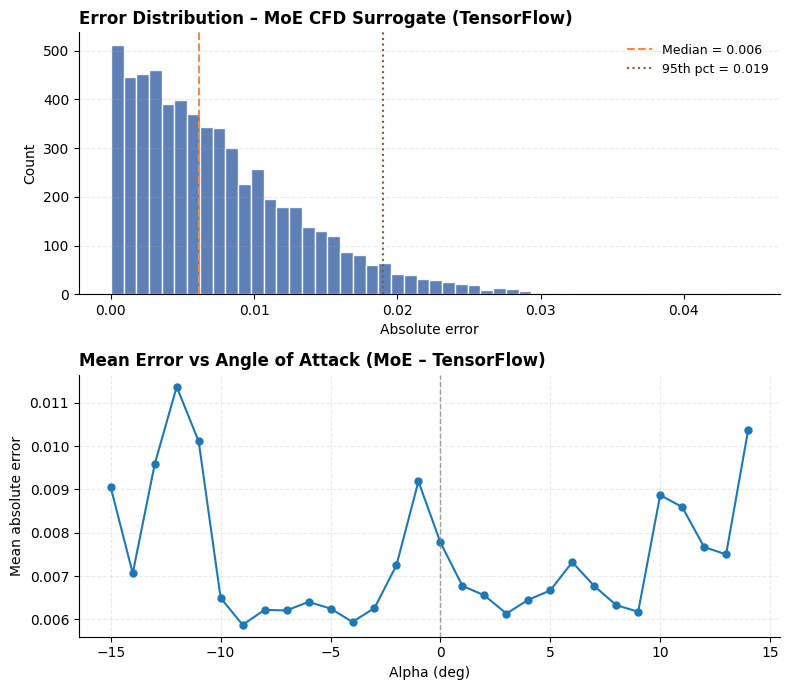

In [39]:
# ---------------------------------------------------
# 1) Compute absolute error
# ---------------------------------------------------
err_tf = np.abs(y_hat_tf - y_test_tf)  # shape (N,)

# ---------------------------------------------------
# 2) Error histogram + Error vs Alpha (2-subplots)
# ---------------------------------------------------
bins_alpha = np.linspace(-15, 15, 31)
bin_idx = np.digitize(alpha_test, bins_alpha)
mean_err_tf = np.full(len(bins_alpha) - 1, np.nan)

for i in range(1, len(bins_alpha)):
    m = bin_idx == i
    if m.any():
        mean_err_tf[i-1] = err_tf[m].mean()

# บาง bin อาจไม่มีข้อมูล ให้ข้ามตอน plot
valid = ~np.isnan(mean_err_tf)

# ค่าที่ใช้ annotate บน histogram
median_err = np.median(err_tf)
p95_err = np.percentile(err_tf, 95)

fig, axes = plt.subplots(2, 1, figsize=(8, 7), sharex=False)

# ---------------------------------------------------
# (a) Error distribution histogram
# ---------------------------------------------------
ax1 = axes[0]

ax1.hist(
    err_tf,
    bins=50,
    color="#4c72b0",
    edgecolor="white",
    alpha=0.9,
)
ax1.set_xlabel("Absolute error", fontsize=10)
ax1.set_ylabel("Count", fontsize=10)
ax1.set_title(
    "Error Distribution – MoE CFD Surrogate (TensorFlow)",
    fontsize=12,
    fontweight="bold",
    loc="left",
)

# เส้น median และ 95th percentile
ax1.axvline(median_err, color="#ff8a3c", linestyle="--", linewidth=1.5,
            label=f"Median = {median_err:.3f}")
ax1.axvline(p95_err, color="#8c564b", linestyle=":", linewidth=1.5,
            label=f"95th pct = {p95_err:.3f}")

ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.grid(axis="y", linestyle="--", alpha=0.25)
ax1.legend(frameon=False, fontsize=9, loc="upper right")

# ---------------------------------------------------
# (b) Mean absolute error vs alpha
# ---------------------------------------------------
ax2 = axes[1]

ax2.plot(
    bins_alpha[:-1][valid],
    mean_err_tf[valid],
    marker="o",
    linestyle="-",
    linewidth=1.5,
    markersize=5,
)

ax2.axvline(0.0, color="#888888", linestyle="--", linewidth=1.0, alpha=0.8)

ax2.set_xlabel("Alpha (deg)", fontsize=10)
ax2.set_ylabel("Mean absolute error", fontsize=10)
ax2.set_title(
    "Mean Error vs Angle of Attack (MoE – TensorFlow)",
    fontsize=12,
    fontweight="bold",
    loc="left",
)

ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)
ax2.grid(True, linestyle="--", alpha=0.25)

plt.tight_layout()
plt.show()

In [37]:
# ต้องรันทันทีหลัง train model_tf เสร็จ

# 1) Forward pass แบบคืนทุกค่า (prediction, gates, expert outputs)
y_hat_tf, gates_tf, experts_tf = model_tf(
    X_test_tf, training=False, return_all=True
)

# 2) แปลงเป็น numpy
gates_tf   = gates_tf.numpy()
experts_tf = experts_tf.numpy()
y_hat_tf   = y_hat_tf.numpy().ravel()

# 3) เลือก expert ที่มี weight สูงสุดในแต่ละ sample
winner_tf = gates_tf.argmax(axis=1)

print("winner_tf shape:", winner_tf.shape)
print("unique experts used:", np.unique(winner_tf))

winner_tf shape: (6000,)
unique experts used: [0 1 2]


winner_tf shape: (6000,)
unique experts used: [0 1 2]


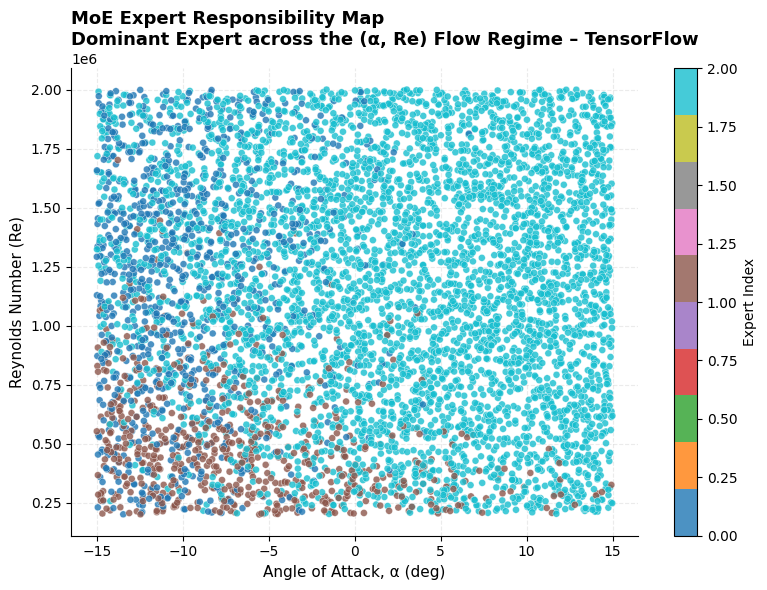

In [40]:
# -------------------------------------------------------
# 1) Forward pass (หลัง train เสร็จ)
# -------------------------------------------------------
y_hat_tf, gates_tf, experts_tf = model_tf(
    X_test_tf, training=False, return_all=True
)

# numpy conversion
gates_tf   = gates_tf.numpy()
experts_tf = experts_tf.numpy()
y_hat_tf   = y_hat_tf.numpy().ravel()

# winner expert per sample
winner_tf = gates_tf.argmax(axis=1)

print("winner_tf shape:", winner_tf.shape)
print("unique experts used:", np.unique(winner_tf))

# Extract flow condition (AoA, Re)
Re_test = X_test[:, 2]

# -------------------------------------------------------
# 2) Plot: Dominant Expert over (Alpha, Re)
# -------------------------------------------------------
plt.figure(figsize=(8, 6))

sc = plt.scatter(
    alpha_test,
    Re_test,
    c=winner_tf,
    cmap="tab10",
    s=25,            # bigger points
    alpha=0.8,
    edgecolors="white",
    linewidth=0.3
)

# Axes labels
plt.xlabel("Angle of Attack, α (deg)", fontsize=11)
plt.ylabel("Reynolds Number (Re)", fontsize=11)

# Narrative title
plt.title(
    "MoE Expert Responsibility Map\n"
    "Dominant Expert across the (α, Re) Flow Regime – TensorFlow",
    fontsize=13,
    loc="left",
    fontweight="bold"
)

# Declutter for clean research style
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(True, linestyle="--", alpha=0.25)
ax.set_axisbelow(True)

# Colorbar
cbar = plt.colorbar(sc)
cbar.set_label("Expert Index", fontsize=10)

plt.tight_layout()
plt.show()